# **Context**
1. Library setup
2. Data collection
3. Data cleaning & EDA
4. Feature preparation
5. LSTM model building & training
6. Testing, prediction & visualization

In [62]:
# !pip show streamlit

In [63]:
# if not install the install it using above pip
# note: dont install again and again
# check using "!pip list"

# !pip install yfinance
!pip install streamlit
# !pip install tensorflow
# !pip install pandas
# !pip install numpy
# !pip install streamlit pyngrok
!pip install pyngrok

# Check verison
# print("NumPy:", np.__version__)
# print("Pandas:", pd.__version__)
# print("TensorFlow:", tf.__version__)

# **1. Installing required libraries Setup**
**Purpose of libraries:**
- **`yfinance`** : download stock market data
- **`pandas`** : data handling
- **`numpy`** : numerical operations
- **`streamlit`** : web app
- **`pyngrok`** : expose local app publicly
- **`Matplotlib / Seaborn`** : visualization
- **`warnings`** : Handling warnings-Suppresses unnecessary warning messages

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import tensorflow as tf
import matplotlib.dates as mdates


import warnings
warnings.filterwarnings("ignore")

#**2. Define Stock Details (Data Collection)**
**Defines:**
- Start date : Start of finance Date
- End date: End of Finance Date
- Stock ticker symbol (Google)

**Download stock data**
- Downloads historical stock data from Yahoo Finance
- Stores it in DataFrame df

**Columns include:** Open, High, Low, Close, Adj Close, Volume

In [65]:
import datetime

start = "2015-01-01"
end = datetime.date.today().strftime("%Y-%m-%d")
Stock = "GOOG"

df = yf.download(Stock, start, end)

[*********************100%***********************]  1 of 1 completed


# **3. Data Cleaning & EDA**

In [66]:
# check 1st 5 row
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
2015-01-05,25.414497,25.931818,25.374438,25.878899,41196796
2015-01-06,24.825466,25.528499,24.780462,25.470387,57998800
2015-01-07,24.782932,25.086796,24.711219,25.074728,41301082
2015-01-08,24.861076,24.900642,24.283418,24.629123,67071641


**Fix multi-level columns**
- Sometimes yfinance returns multi-index columns
- `droplevel(1)` removes extra level

In [67]:
df.columns = df.columns.droplevel(1)

In [68]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
2015-01-05,25.414497,25.931818,25.374438,25.878899,41196796
2015-01-06,24.825466,25.528499,24.780462,25.470387,57998800
2015-01-07,24.782932,25.086796,24.711219,25.074728,41301082
2015-01-08,24.861076,24.900642,24.283418,24.629123,67071641
...,...,...,...,...,...
2026-05-22,379.380005,384.869995,378.260010,383.260010,13382800
2026-05-26,384.839996,385.390015,379.140015,380.994995,16150900
2026-05-27,384.829987,389.725006,382.000000,382.765015,16893100


**`None`** removes column index name

In [69]:
# remove column index name if present
df.columns.name = None

In [70]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
2015-01-05,25.414497,25.931818,25.374438,25.878899,41196796
2015-01-06,24.825466,25.528499,24.780462,25.470387,57998800
2015-01-07,24.782932,25.086796,24.711219,25.074728,41301082
2015-01-08,24.861076,24.900642,24.283418,24.629123,67071641


**Reset index**
- Converts Date index into a normal column
- Easier for plotting and processing

In [71]:
#reset index
df = df.reset_index()
df.head(2)

,Date,Close,High,Low,Open,Volume
0,2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
1,2015-01-05,25.414497,25.931818,25.374438,25.878899,41196796


**Check missing values**
-  no null value found

In [72]:
#To check Null
df.isna().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


**Check data types**

In [73]:
# to check datatypes of each column
df.dtypes

,0
Date,datetime64[ns]
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


**Visualize missing values**
- for more better understanding

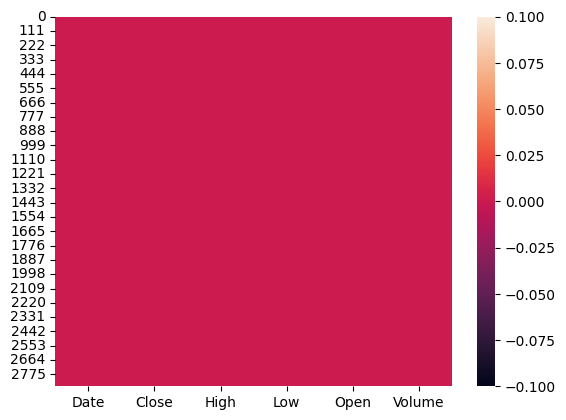

In [74]:
#To visualized null value with the help of heatmap: if incase
sns.heatmap(df.isna())
plt.show()

**Check duplicat value if any**

In [75]:
# To show duplicate record
df.duplicated().sum()

np.int64(0)

**Correlation matrix**
- Shows correlation between numerical columns
- Helps understand feature relationships

In [76]:
# correlation
df.corr().style.background_gradient()

,Date,Close,High,Low,Open,Volume
Date,1.000000,0.873566,0.874064,0.873631,0.873672,-0.375634
Close,0.873566,1.000000,0.999866,0.999863,0.999674,-0.345665
High,0.874064,0.999866,1.000000,0.999835,0.999850,-0.341790
Low,0.873631,0.999863,0.999835,1.000000,0.999847,-0.348892
Open,0.873672,0.999674,0.999850,0.999847,1.000000,-0.344583
Volume,-0.375634,-0.345665,-0.341790,-0.348892,-0.344583,1.000000


**Graph 1 - Closing price vs time**

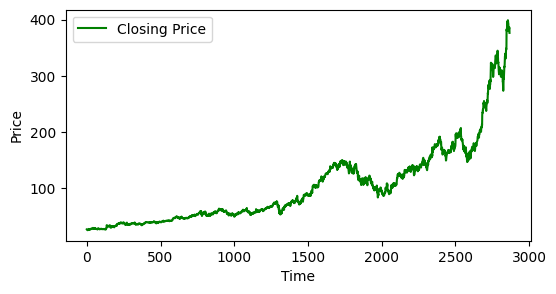

In [77]:
# visualized Closing Price Vs Time Chart
plt.figure(figsize=(6,3))
plt.plot(df.Close,"g", label = "Closing Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

**100-day moving average** Smoothens price fluctuations

**Graph 2 - Plot price with 100MA**
- Red line : 100-day MA
- Green line : actual price

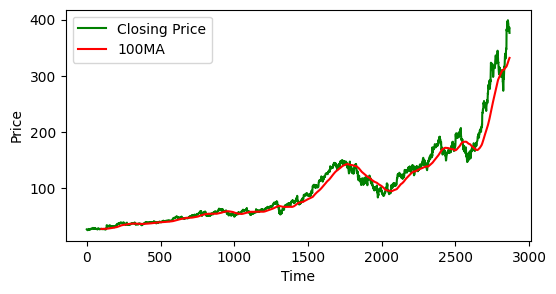

In [78]:
# moving price of 100 days

ma100 = df.Close.rolling(100).mean()
plt.figure(figsize=(6,3))
plt.plot(df.Close,"g", label = "Closing Price")
plt.plot(ma100,"r", label = "100MA")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

**200-day moving average** Long-term trend indicator  
**Graph 3 - Plot price with 200MA**
- Blue line : 200-day MA

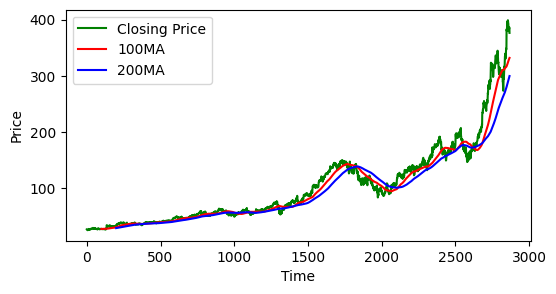

In [79]:
# moving avg price of 200 days
ma100 = df.Close.rolling(100).mean()
ma200 = df.Close.rolling(200).mean()
plt.figure(figsize=(6,3))
plt.plot(df.Close,"g", label = "Closing Price")
plt.plot(ma100,"r", label = "100MA")
plt.plot(ma200,"b", label = "200MA")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

**Dataset shape**
- Returns (rows, columns) --> 3272 rows, 6 columns

In [80]:
#how many rows and columns in given dataset
df.shape

(2868, 6)

# **4. Feature Preparation**

**Train-test split (80-20)** : Uses only Close price --> Time-series split (no random shuffling)


In [81]:
#splitting data for training(80%) and testing(20%)

data_train  = pd.DataFrame(df["Close"][0:int(len(df)*0.80)])
data_test  = pd.DataFrame(df["Close"][int(len(df)*0.80): int(len(df))])

print(data_train.shape, data_test.shape)

(2294, 1) (574, 1)


In [82]:
data_train

,Close
0,25.955561
1,25.414497
2,24.825466
3,24.782932
4,24.861076
...,...
2289,145.485580
2290,146.021179
2291,148.996750
2292,147.518875


In [83]:
data_test

,Close
2294,145.941833
2295,142.767914
2296,140.605637
2297,141.042038
2298,142.668701
...,...
2863,379.380005
2864,384.839996
2865,384.829987
2866,386.119995


**Feature Scaling**
- Scales values between 0 and 1
- Required for LSTM performance

In [84]:
# scale the model
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

**Fit & transform training data**
- Learns min & max from training data
- Converts data to scaled NumPy array

In [85]:
data_train_scale = scaler.fit_transform(data_train)

In [86]:
data_train_scale   # op is in the array form

array([[0.01234712],
       [0.00815995],
       [0.00360155],
       ...,
       [0.96453788],
       [0.9531009 ],
       [0.93498613]])

In [87]:
#check shape of array
data_train_scale.shape

(2294, 1)

In [88]:
#check type
type(data_train_scale)

numpy.ndarray

**Create sequences for LSTM**
- x_train: past 100 days  
- y_train: next day price

Uses 100 previous days to predict next day


In [89]:
# train model
x_train = []
y_train = []

for i in range(100, data_train_scale.shape[0]):
  x_train.append(data_train_scale[i-100 : i])
  y_train.append(data_train_scale[i , 0])

In [90]:
x_train

[array([[0.01234712],
        [0.00815995],
        [0.00360155],
        [0.00327239],
        [0.00387713],
        [0.00138553],
        [0.        ],
        [0.00138933],
        [0.00318439],
        [0.00353649],
        [0.00594391],
        [0.00549229],
        [0.00975598],
        [0.01601376],
        [0.01814176],
        [0.0163276 ],
        [0.00998181],
        [0.00667878],
        [0.00693139],
        [0.01606353],
        [0.01375177],
        [0.01404266],
        [0.01156253],
        [0.0134073 ],
        [0.01471629],
        [0.013503  ],
        [0.01698973],
        [0.01661848],
        [0.01928233],
        [0.02160939],
        [0.01924792],
        [0.0180461 ],
        [0.01925937],
        [0.01775903],
        [0.01506456],
        [0.0166644 ],
        [0.01964211],
        [0.0240857 ],
        [0.0252033 ],
        [0.03015595],
        [0.03103624],
        [0.03093288],
        [0.03168305],
        [0.02875701],
        [0.02920293],
        [0

In [91]:
y_train

[np.float64(0.018643930448131313),
 np.float64(0.01570024207356674),
 np.float64(0.016421739387140588),
 np.float64(0.018413635826887875),
 np.float64(0.01884733128653243),
 np.float64(0.017461829131487278),
 np.float64(0.0161685068193895),
 np.float64(0.013673835389974603),
 np.float64(0.013620121627206716),
 np.float64(0.01745799137981932),
 np.float64(0.01665973903288659),
 np.float64(0.01578470213142824),
 np.float64(0.01381584696227195),
 np.float64(0.014180448131310142),
 np.float64(0.014606438566452135),
 np.float64(0.01747335714707446),
 np.float64(0.01745799137981932),
 np.float64(0.018033698411761223),
 np.float64(0.018912573064887528),
 np.float64(0.01789937710338313),
 np.float64(0.016897650115132556),
 np.float64(0.015539056503513005),
 np.float64(0.011635930211961965),
 np.float64(0.011248302532916088),
 np.float64(0.011758723504752905),
 np.float64(0.01235747180728583),
 np.float64(0.012150203696050077),
 np.float64(0.012979187577493057),
 np.float64(0.00983595087677866)

In [92]:
# cehck type of training data
type(x_train), type(y_train)

(list, list)

**Convert to NumPy arrays**: Required format for Keras LSTM

In [93]:
#convert to array
x_train, y_train = np.array(x_train), np.array(y_train)

In [94]:
type(x_train), type(y_train)

(numpy.ndarray, numpy.ndarray)

In [95]:
x_train

array([[[0.01234712],
        [0.00815995],
        [0.00360155],
        ...,
        [0.01877058],
        [0.01578086],
        [0.01864772]],

       [[0.00815995],
        [0.00360155],
        [0.00327239],
        ...,
        [0.01578086],
        [0.01864772],
        [0.01864393]],

       [[0.00360155],
        [0.00327239],
        [0.00387713],
        ...,
        [0.01864772],
        [0.01864393],
        [0.01570024]],

       ...,

       [[0.87810852],
        [0.87711082],
        [0.84456539],
        ...,
        [0.92761741],
        [0.93736565],
        [0.94151054]],

       [[0.87711082],
        [0.84456539],
        [0.81977257],
        ...,
        [0.93736565],
        [0.94151054],
        [0.96453788]],

       [[0.84456539],
        [0.81977257],
        [0.81892838],
        ...,
        [0.94151054],
        [0.96453788],
        [0.9531009 ]]])

In [96]:
y_train

array([0.01864393, 0.01570024, 0.01642174, ..., 0.96453788, 0.9531009 ,
       0.93498613])

# **5. LSTM Model Building & Training**

**Import LSTM libraries**
- LSTM : sequence learning
- Dropout : avoid overfitting
- Dense : output layer

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

**Build LSTM model** Sequential model = layer-by-layer stack  
**Add LSTM + Dropout layers**
- return_sequences=True -> pass output to next LSTM
- Dropout removes 20% neurons randomly  

**Output layer** : Predicts single value (next day price)

In [98]:
model = Sequential()
model.add(LSTM(units = 64,return_sequences = True,
               input_shape = (x_train.shape[1],2)))
model.add(Dropout(0.2))

model.add(LSTM(units = 64,return_sequences = False))
model.add(Dropout(0.2))

model.add(Dense(units = 25,activation = "relu"))
model.add(Dense(units = 1))

In [99]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,827 (202.45 KB)

 Trainable params: 51,827 (202.45 KB)

 Non-trainable params: 0 (0.00 B)

**Compile model**
- Adam : efficient optimizer
- MSE : regression loss

In [100]:
model.compile(optimizer = "adam", loss = "mean_squared_error")

**Train model**
- x_train / y_train: The input data and the correct answers (labels).
- epochs = 50: The model goes through the entire dataset 50 times.
- batch_size = 32: The model updates its "knowledge" after looking at 32 samples at a time.
- verbose = 1: Shows a progress bar so you can see the training status.

In [101]:
model.fit(x_train, y_train, epochs = 50, batch_size=32, verbose=1)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0313
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0026
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0019
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoc

**model.summary()** is a diagnostic snapshot of your neural network's structure.
- **Layer (type):** Lists your building blocks (LSTM for memory, Dropout to prevent cheating/overfitting, Dense for the final result).
- **Output Shape:** Shows how the data is reshaped at each step. The None is just a placeholder for your batch size (32).
- **Param #:** The number of "brain cells" (weights) in each layer. More params = more learning capacity, but slower training.
- **Trainable params:** The total number of weights (178,761) the model will actually adjust during training to get the right answers.

**Summary:** It’s a "blueprint" check to ensure your layers are connected correctly before you start the time-consuming training process.

In [102]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,483 (607.36 KB)

 Trainable params: 51,827 (202.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 103,656 (404.91 KB)

**Save model**

In [103]:
model.save("Keras_Model.keras")

# **3. Prepare Test Data**
- Adds last 100 days to test data. Needed for sequence creation

In [104]:
# Take last 100 days from full dataset
last_100_days = df["Close"].tail(100).values.reshape(-1,1)
last_100_days

array([[314.32855225],
       [322.20300293],
       [325.78048706],
       [328.90829468],
       [332.49575806],
       [336.19314575],
       [336.07324219],
       [332.92547607],
       [330.10745239],
       [321.93319702],
       [328.14883423],
       [330.60708618],
       [328.1987915 ],
       [333.35516357],
       [334.76416016],
       [336.04327393],
       [338.42160034],
       [338.29168701],
       [344.65719604],
       [340.46017456],
       [333.10531616],
       [331.09674072],
       [322.87255859],
       [324.17163086],
       [318.40570068],
       [311.11080933],
       [309.15219116],
       [305.80456543],
       [302.60681152],
       [303.7260437 ],
       [303.34628296],
       [314.67831421],
       [311.47058105],
       [310.70114136],
       [312.80963135],
       [306.93377686],
       [311.21075439],
       [306.14431763],
       [303.34628296],
       [303.23638916],
       [300.69815063],
       [298.08999634],
       [306.01000977],
       [306

**Scale test data**

In [105]:
# Scale using trained scaler
data_test_scale = scaler.transform(data_test)
data_test_scale

array([[0.9408965 ],
       [0.91633418],
       [0.89960076],
       [0.90297798],
       [0.91556639],
       [0.92692637],
       [0.92669635],
       [0.87649666],
       [0.88685918],
       [0.86636465],
       [0.88440255],
       [0.87135396],
       [0.84157182],
       [0.838348  ],
       [0.82898353],
       [0.84955482],
       [0.8576141 ],
       [0.87795501],
       [0.88317447],
       [0.89200177],
       [0.91940414],
       [0.90274783],
       [0.95118215],
       [0.94688351],
       [0.96039287],
       [0.95317778],
       [0.97643538],
       [0.97167633],
       [0.97589786],
       [0.9777401 ],
       [0.98019626],
       [1.01274157],
       [1.007906  ],
       [1.01174399],
       [0.9777401 ],
       [0.99309169],
       [1.00997863],
       [1.02533011],
       [1.02164575],
       [1.04567078],
       [1.03338962],
       [1.01143685],
       [1.0089037 ],
       [1.01565862],
       [1.02011041],
       [1.00675468],
       [1.02387164],
       [1.038

In [106]:
data_test_scale.shape

(574, 1)

**Create test sequences** same sliding window logic as training data

In [107]:
# Prepare the test sequences
x_test = []
y_test = []

# Using the 100 days look-back window
for i in range(100, data_test_scale.shape[0]):
    x_test.append(data_test_scale[i-100:i])
    y_test.append(data_test_scale[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

# Generate predictions
y_predict = model.predict(x_test)

# Convert back to original scale
y_predict = scaler.inverse_transform(y_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [108]:
x_test.shape, y_test.shape

((474, 100, 1), (474, 1))

**Prediction**: Predicts future stock prices

In [109]:
#find the r2_score

from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.5780630833042504

In [110]:
# check shape of predicted
y_predict.shape

(474, 1)

In [111]:
#check shape of test
y_test.shape

(474, 1)

In [112]:
y_test

array([[191.30859375],
       [185.98620605],
       [185.46984863],
       [186.86994934],
       [184.19882202],
       [181.33905029],
       [177.96287537],
       [178.13166809],
       [182.06391907],
       [182.31217957],
       [173.1468811 ],
       [167.97346497],
       [167.49679565],
       [169.92964172],
       [170.65447998],
       [171.93545532],
       [171.24035645],
       [167.21876526],
       [159.51319885],
       [159.41389465],
       [159.62242126],
       [162.69075012],
       [164.22988892],
       [162.79998779],
       [164.76611328],
       [160.89344788],
       [162.02546692],
       [163.58444214],
       [167.21876526],
       [167.77484131],
       [166.45419312],
       [164.32919312],
       [166.25556946],
       [166.75205994],
       [165.21295166],
       [163.34611511],
       [162.25384521],
       [163.951828  ],
       [157.49745178],
       [156.70306396],
       [157.48753357],
       [151.06289673],
       [148.68655396],
       [149

The **`scale_`** attribute allows you to inspect the parameters learned during the fitting process

In [113]:
# scaler.scale_

**Inverse scaling**: Converts scaled values back to original prices

**Final visualization**
- Compares actual vs predicted prices
- Red close to green = good model

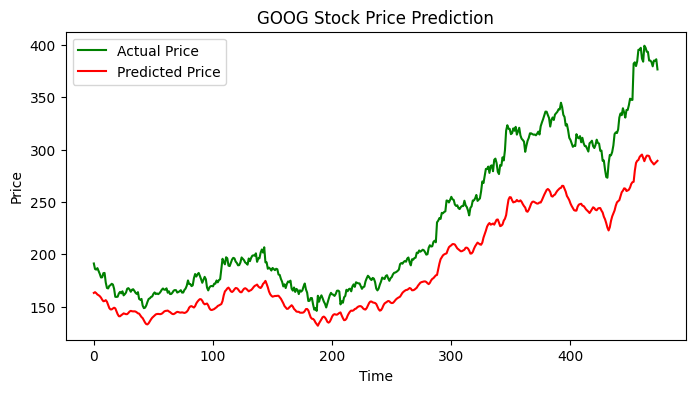

In [114]:
# Visualization: Actual Vs Predicted
plt.figure(figsize = (8,4))
plt.plot(y_test, "g", label = "Actual Price")
plt.plot(y_predict, "r", label = "Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title(f"{Stock} Stock Price Prediction")
plt.legend()
plt.show()

#**Deploy**

**Import ngrok**
- Imports ngrok module from pyngrok
- ngrok creates a secure tunnel from local server to the public internet

**Set ngrok authentication token**
- Authenticates your machine with ngrok servers
- Token is obtained from ngrok dashboard
- Required to:
  - Avoid connection limits
  - Enable stable tunnels

**Without this--> ngrok may fail or disconnect**

In [115]:
# from pyngrok import ngrok
# ngrok.set_auth_token("39QCG9DrRsWE0YpeOVyPHooBh1u_4pQFwejLbsdoyHeGf62R6")

**Run Streamlit app in background**

- **!** : Executes a shell command

**streamlit run app.py**
- Starts Streamlit server
- Runs your Streamlit application written in app.py
- By default, Streamlit runs on: http: // local host: 8501

**&**
- Runs the command in background
- So notebook execution doesn’t stop

**&>/content/logs.txt**
- Redirects all logs/output to a file
- Keeps notebook clean
- Useful for debugging if app crashes

**overall meanings** --> Your Streamlit app is now running locally on port 8501

In [116]:
# !streamlit run app.py &>/content/logs.txt &

**Create public URL using ngrok**
- Creates a tunnel from: localhost:8501:  public ngrok URL

**Print public URL**
- This is the deployment URL

In [117]:
# # pulic ngrok
# public_url = ngrok.connect(8501)
# print("🚀 Your Streamlit app is live at:", public_url)

“We deployed the Streamlit application using ngrok, which exposes the locally running Streamlit server to the internet by creating a secure public tunnel.”

# Use incase ngork show error

In [118]:
# if in case facing error with ngrok usw this line of code

# from pyngrok import ngrok
# ngrok.kill()

# !rm -rf ~/.ngrok2
# !rm -rf /root/.ngrok2


In [119]:
# 135deg, #232526, #414345, #000000 -----> gray